In [1]:
import pandas as pd

df = pd.read_csv('2019-Oct.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [2]:
smartphone_df = df[df['category_code'] == 'electronics.smartphone'].copy()

In [3]:
#정렬 + unknown처리
df = smartphone_df.sort_values(['user_session', 'event_time']).copy()
df['brand'] = df['brand'].fillna('unknown')

In [4]:
grouped = df.groupby(['user_session', 'product_id'])

In [5]:
event_first_time = (
    smartphone_df
    .groupby(['user_session', 'product_id', 'event_type'])['event_time']
    .min()
    .unstack()
    .reset_index()
)

for col in ['view', 'cart', 'purchase']:
    if col not in event_first_time.columns:
        event_first_time[col] = pd.NaT

# 존재 여부 컬럼 따로 생성
event_first_time['has_view'] = event_first_time['view'].notna()
event_first_time['has_cart'] = event_first_time['cart'].notna()
event_first_time['has_purchase'] = event_first_time['purchase'].notna()

# 순서 검증
event_first_time['view_to_cart'] = (
    event_first_time['has_view'] &
    event_first_time['has_cart'] &
    (event_first_time['view'] < event_first_time['cart'])
)

event_first_time['view_to_cart_to_purchase'] = (
    event_first_time['has_view'] &
    event_first_time['has_cart'] &
    event_first_time['has_purchase'] &
    (event_first_time['view'] < event_first_time['cart']) &
    (event_first_time['cart'] < event_first_time['purchase'])
)

funnel_df = event_first_time[[
    'user_session',
    'product_id',
    'has_view',
    'view_to_cart',
    'view_to_cart_to_purchase'
]].rename(columns={
    'has_view': 'view'
})

In [6]:
funnel_summary = pd.DataFrame({
    'step': ['view', 'view_to_cart', 'view_to_cart_to_purchase'],
    'count': [
        funnel_df['view'].sum(),
        funnel_df['view_to_cart'].sum(),
        funnel_df['view_to_cart_to_purchase'].sum()
    ]
})

funnel_summary['conversion_rate_vs_view'] = (
    funnel_summary['count'] / funnel_summary.loc[0, 'count'] * 100
)

funnel_summary

,step,count,conversion_rate_vs_view
0,view,7058659,100.000000
1,view_to_cart,364365,5.161958
2,view_to_cart_to_purchase,191430,2.711988


In [7]:
view_sessions = funnel_df['view'].sum()
view_to_cart_sessions = funnel_df['view_to_cart'].sum()
view_to_cart_to_purchase_sessions = funnel_df['view_to_cart_to_purchase'].sum()

view_to_cart_rate = view_to_cart_sessions / view_sessions
cart_to_purchase_rate = view_to_cart_to_purchase_sessions / view_to_cart_sessions
total_conversion_rate = view_to_cart_to_purchase_sessions / view_sessions

In [8]:
target_brands = ['samsung', 'apple', 'xiaomi']

df_flow = df[df['brand'].isin(target_brands)].copy()
df_flow = df_flow.sort_values(['user_session', 'event_time'])

flow_df = (
    df_flow[df_flow['event_type'].isin(['view', 'cart', 'purchase'])]
    .groupby(['user_session', 'event_type'])['brand']
    .first()
    .unstack()
    .reset_index()
)

flow_df = flow_df.rename(columns={
    'view': 'view_brand',
    'cart': 'cart_brand',
    'purchase': 'purchase_brand'
})

flow_df.head()

event_type,user_session,cart_brand,purchase_brand,view_brand
0,00000056-a206-40dd-b174-a072550fa38c,NaN,NaN,apple
1,00000083-8816-4d58-a9b8-f52f54186edc,samsung,samsung,samsung
2,000001fd-1f89-45e8-a3ce-fe3218cabfad,samsung,samsung,samsung
3,00000a05-fa4e-4486-b5e8-c8bffa63b422,NaN,NaN,samsung
4,00000aaa-d774-49bc-9c31-0c9f6e1c2f0a,NaN,NaN,xiaomi


In [9]:
def classify_flow(row):
    v = row.get('view_brand')
    c = row.get('cart_brand')
    p = row.get('purchase_brand')

    brands = [x for x in [v, c, p] if pd.notna(x)]

    if pd.isna(v) or pd.isna(p):
        return 'no_purchase_or_no_view'

    if pd.notna(c):
        if v == c == p:
            return 'same_brand'
        elif v != c and c == p:
            return 'view_to_cart_switch'
        elif v == c and c != p:
            return 'cart_to_purchase_switch'
        elif len(set(brands)) == 3:
            return 'multi_brand_exploration'
        else:
            return 'etc'
    else:
        if v == p:
            return 'direct_same_purchase'
        else:
            return 'direct_switch_purchase'

flow_df['pattern'] = flow_df.apply(classify_flow, axis=1)

flow_df['pattern'].value_counts()

pattern
no_purchase_or_no_view     2488727
same_brand                  156658
direct_same_purchase         83699
view_to_cart_switch           6148
direct_switch_purchase        3072
cart_to_purchase_switch        848
etc                            661
multi_brand_exploration         38
Name: count, dtype: int64

In [10]:
flow_df['pattern'].value_counts(normalize=True) * 100

pattern
no_purchase_or_no_view     90.834392
same_brand                  5.717756
direct_same_purchase        3.054874
view_to_cart_switch         0.224392
direct_switch_purchase      0.112123
cart_to_purchase_switch     0.030951
etc                         0.024125
multi_brand_exploration     0.001387
Name: proportion, dtype: float64

view → cart 변경 분석

In [11]:
vc_switch = flow_df[flow_df['pattern'] == 'view_to_cart_switch'].copy()

vc_matrix = (
    vc_switch.groupby(['view_brand', 'cart_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

vc_matrix

,view_brand,cart_brand,count
0,apple,samsung,1838
3,samsung,xiaomi,1587
2,samsung,apple,1454
5,xiaomi,samsung,758
1,apple,xiaomi,356
4,xiaomi,apple,155


cart → purchase 변경 분석

In [12]:
cp_switch = flow_df[flow_df['pattern'] == 'cart_to_purchase_switch'].copy()

cp_matrix = (
    cp_switch.groupby(['cart_brand', 'purchase_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

cp_matrix

,cart_brand,purchase_brand,count
0,apple,samsung,295
3,samsung,xiaomi,203
2,samsung,apple,199
5,xiaomi,samsung,103
1,apple,xiaomi,35
4,xiaomi,apple,13


direct 구매 변경 (view → purchase)

In [13]:
dp_switch = flow_df[flow_df['pattern'] == 'direct_switch_purchase'].copy()

dp_matrix = (
    dp_switch.groupby(['view_brand', 'purchase_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

dp_matrix

,view_brand,purchase_brand,count
3,samsung,xiaomi,966
0,apple,samsung,769
2,samsung,apple,711
5,xiaomi,samsung,300
1,apple,xiaomi,229
4,xiaomi,apple,97


In [14]:
vc_ratio = vc_matrix.copy()

vc_ratio['total_from_view'] = vc_ratio.groupby('view_brand')['count'].transform('sum')
vc_ratio['ratio'] = vc_ratio['count'] / vc_ratio['total_from_view'] * 100

vc_ratio.sort_values(['view_brand', 'ratio'], ascending=[True, False])

,view_brand,cart_brand,count,total_from_view,ratio
0,apple,samsung,1838,2194,83.773929
1,apple,xiaomi,356,2194,16.226071
3,samsung,xiaomi,1587,3041,52.186781
2,samsung,apple,1454,3041,47.813219
5,xiaomi,samsung,758,913,83.023001
4,xiaomi,apple,155,913,16.976999


In [15]:
cp_ratio = cp_matrix.copy()

cp_ratio['total_from_cart'] = cp_ratio.groupby('cart_brand')['count'].transform('sum')
cp_ratio['ratio'] = cp_ratio['count'] / cp_ratio['total_from_cart'] * 100

cp_ratio.sort_values(['cart_brand', 'ratio'], ascending=[True, False])

,cart_brand,purchase_brand,count,total_from_cart,ratio
0,apple,samsung,295,330,89.393939
1,apple,xiaomi,35,330,10.606061
3,samsung,xiaomi,203,402,50.497512
2,samsung,apple,199,402,49.502488
5,xiaomi,samsung,103,116,88.793103
4,xiaomi,apple,13,116,11.206897


In [16]:
dp_ratio = dp_matrix.copy()

dp_ratio['total_from_view'] = dp_ratio.groupby('view_brand')['count'].transform('sum')
dp_ratio['ratio'] = dp_ratio['count'] / dp_ratio['total_from_view'] * 100

dp_ratio.sort_values(['view_brand', 'ratio'], ascending=[True, False])

,view_brand,purchase_brand,count,total_from_view,ratio
0,apple,samsung,769,998,77.054108
1,apple,xiaomi,229,998,22.945892
3,samsung,xiaomi,966,1677,57.602862
2,samsung,apple,711,1677,42.397138
5,xiaomi,samsung,300,397,75.566751
4,xiaomi,apple,97,397,24.433249


구매한 브랜드 기준 소요시간(브랜드 관여)


같은 브랜드를 보고 선택한 소요시간(동일 브랜드)

In [17]:
# view / purchase 시간 + 브랜드 추출
event_time_df = (
    df[df['event_type'].isin(['view', 'purchase'])]
    .sort_values(['user_session', 'event_time'])
)

event_time_pivot = (
    event_time_df
    .groupby(['user_session', 'event_type'])
    .agg({
        'event_time': 'first',
        'brand': 'first'
    })
    .unstack()
)

# 컬럼 정리
event_time_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in event_time_pivot.columns
]

event_time_pivot = event_time_pivot.reset_index()

event_time_pivot.head()

,user_session,event_time_purchase,event_time_view,brand_purchase,brand_view
0,00000056-a206-40dd-b174-a072550fa38c,NaN,2019-10-31 06:23:12 UTC,NaN,apple
1,00000083-8816-4d58-a9b8-f52f54186edc,2019-10-06 11:34:30 UTC,2019-10-06 11:24:45 UTC,samsung,samsung
2,000001fd-1f89-45e8-a3ce-fe3218cabfad,2019-10-25 08:39:11 UTC,2019-10-25 08:30:42 UTC,samsung,samsung
3,00000a05-fa4e-4486-b5e8-c8bffa63b422,NaN,2019-10-07 14:16:54 UTC,NaN,samsung
4,00000aaa-d774-49bc-9c31-0c9f6e1c2f0a,NaN,2019-10-19 12:41:17 UTC,NaN,xiaomi


In [19]:
# event_time datetime 변환
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

# 다시 pivot 생성
event_time_df = (
    df[df['event_type'].isin(['view', 'purchase'])]
    .sort_values(['user_session', 'event_time'])
)

event_time_pivot = (
    event_time_df
    .groupby(['user_session', 'event_type'])
    .agg({
        'event_time': 'first',
        'brand': 'first'
    })
    .unstack()
)

event_time_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in event_time_pivot.columns
]

event_time_pivot = event_time_pivot.reset_index()

# 혹시 모를 문자열 방지
event_time_pivot['event_time_view'] = pd.to_datetime(
    event_time_pivot['event_time_view'], errors='coerce'
)

event_time_pivot['event_time_purchase'] = pd.to_datetime(
    event_time_pivot['event_time_purchase'], errors='coerce'
)

# 구매 도달 시간 계산
event_time_pivot['time_to_purchase_sec'] = (
    event_time_pivot['event_time_purchase'] - event_time_pivot['event_time_view']
).dt.total_seconds()

event_time_pivot['time_to_purchase_hour'] = (
    event_time_pivot['time_to_purchase_sec'] / 3600
)

event_time_pivot.head()

,user_session,event_time_purchase,event_time_view,brand_purchase,brand_view,time_to_purchase_sec,time_to_purchase_hour
0,00000056-a206-40dd-b174-a072550fa38c,NaT,2019-10-31 06:23:12+00:00,NaN,apple,NaN,NaN
1,00000083-8816-4d58-a9b8-f52f54186edc,2019-10-06 11:34:30+00:00,2019-10-06 11:24:45+00:00,samsung,samsung,585.0,0.162500
2,000001fd-1f89-45e8-a3ce-fe3218cabfad,2019-10-25 08:39:11+00:00,2019-10-25 08:30:42+00:00,samsung,samsung,509.0,0.141389
3,00000a05-fa4e-4486-b5e8-c8bffa63b422,NaT,2019-10-07 14:16:54+00:00,NaN,samsung,NaN,NaN
4,00000aaa-d774-49bc-9c31-0c9f6e1c2f0a,NaT,2019-10-19 12:41:17+00:00,NaN,xiaomi,NaN,NaN


In [20]:
purchase_time_df = event_time_pivot[
    event_time_pivot['event_time_view'].notna() &
    event_time_pivot['event_time_purchase'].notna()
].copy()

In [21]:
purchase_time_by_brand = (
    purchase_time_df.groupby('brand_purchase')
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
    .sort_values('avg_time')
)

purchase_time_by_brand

,brand_purchase,avg_time,median_time,count
25,texet,0.052519,0.029167,15
13,irbis,0.053556,0.040000,5
0,apple,0.071449,0.032778,97228
10,htc,0.080737,0.053889,26
5,fly,0.083258,0.036111,37
21,prestigio,0.084902,0.043056,232
22,samsung,0.085419,0.041667,119814
6,gionee,0.095484,0.046389,27
31,zte,0.098005,0.061944,137
14,jinga,0.098086,0.058750,36


In [22]:
same_brand_df = purchase_time_df[
    purchase_time_df['brand_view'] == purchase_time_df['brand_purchase']
].copy()

same_brand_time = (
    same_brand_df.groupby('brand_purchase')
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
    .sort_values('avg_time')
)

same_brand_time

,brand_purchase,avg_time,median_time,count
24,texet,0.027616,0.026389,12
5,fly,0.042523,0.027778,24
6,gionee,0.044542,0.026667,17
23,tecno,0.047474,0.032222,54
8,haier,0.050139,0.020694,28
20,prestigio,0.052150,0.031944,151
27,unknown,0.054539,0.033611,199
30,zte,0.055604,0.037778,80
13,irbis,0.056944,0.046806,4
14,jinga,0.060598,0.038611,13


In [23]:
purchase_time_df['same_brand'] = (
    purchase_time_df['brand_view'] == purchase_time_df['brand_purchase']
)

compare_time = (
    purchase_time_df.groupby(['brand_purchase', 'same_brand'])
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
)

compare_time

,brand_purchase,same_brand,avg_time,median_time,count
0,apple,False,0.142889,0.075556,2976
1,apple,True,0.069193,0.031944,94252
2,asus,False,0.108333,0.108333,2
3,asus,True,0.111204,0.104167,9
4,blackberry,True,0.129881,0.036111,7
...,...,...,...,...,...
57,vivo,True,0.109075,0.035556,1368
58,xiaomi,False,0.296890,0.135000,4794
59,xiaomi,True,0.121534,0.048056,28450
60,zte,False,0.157515,0.085833,57


In [24]:
target_brands = ['samsung', 'apple', 'xiaomi']

purchase_time_by_brand = purchase_time_by_brand[
    purchase_time_by_brand['brand_purchase'].isin(target_brands)
]

same_brand_time = same_brand_time[
    same_brand_time['brand_purchase'].isin(target_brands)
]

compare_time = compare_time[
    compare_time['brand_purchase'].isin(target_brands)
]

In [25]:
# 전체 vs 동일 브랜드 비교
final_time_compare = purchase_time_by_brand.merge(
    same_brand_time,
    on='brand_purchase',
    suffixes=('_all', '_same')
)

# 보기 좋게 정리
final_time_compare = final_time_compare[
    [
        'brand_purchase',
        'avg_time_all', 'median_time_all',
        'avg_time_same', 'median_time_same',
        'count_all', 'count_same'
    ]
]

# 차이 계산
final_time_compare['time_diff'] = (
    final_time_compare['avg_time_all'] - final_time_compare['avg_time_same']
)

final_time_compare.sort_values('avg_time_all')

,brand_purchase,avg_time_all,median_time_all,avg_time_same,median_time_same,count_all,count_same,time_diff
0,apple,0.071449,0.032778,0.069193,0.031944,97228,94252,0.002256
1,samsung,0.085419,0.041667,0.079468,0.040000,119814,114131,0.005950
2,xiaomi,0.146821,0.055833,0.121534,0.048056,33244,28450,0.025288


In [26]:
# same_brand True/False를 보기 좋게
compare_time_pivot = compare_time.pivot(
    index='brand_purchase',
    columns='same_brand',
    values='avg_time'
).reset_index()

compare_time_pivot.columns = [
    'brand',
    'cross_purchase_time',  # False
    'same_brand_time'       # True
]

# 차이 계산
compare_time_pivot['diff'] = (
    compare_time_pivot['cross_purchase_time'] -
    compare_time_pivot['same_brand_time']
)

compare_time_pivot.sort_values('cross_purchase_time')

,brand,cross_purchase_time,same_brand_time,diff
0,apple,0.142889,0.069193,0.073696
1,samsung,0.204912,0.079468,0.125444
2,xiaomi,0.296890,0.121534,0.175356


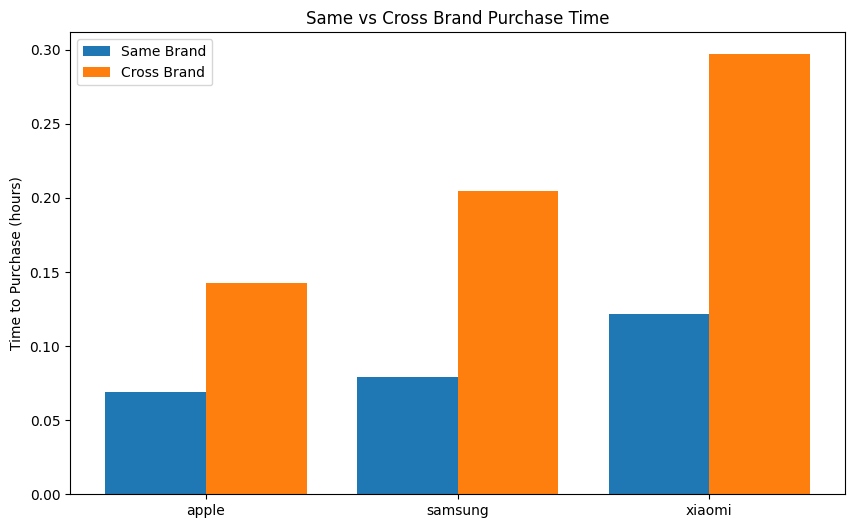

In [27]:
import matplotlib.pyplot as plt

x = range(len(compare_time_pivot))

plt.figure(figsize=(10,6))

plt.bar(
    [i - 0.2 for i in x],
    compare_time_pivot['same_brand_time'],
    width=0.4,
    label='Same Brand'
)

plt.bar(
    [i + 0.2 for i in x],
    compare_time_pivot['cross_purchase_time'],
    width=0.4,
    label='Cross Brand'
)

plt.xticks(x, compare_time_pivot['brand'])
plt.ylabel('Time to Purchase (hours)')
plt.title('Same vs Cross Brand Purchase Time')
plt.legend()

plt.show()

In [28]:
# 시간 구간화
purchase_time_df['time_bucket'] = pd.cut(
    purchase_time_df['time_to_purchase_hour'],
    bins=[0, 1, 6, 24, 48, 999],
    labels=['<1h', '1-6h', '6-24h', '1-2d', '2d+']
)

# 브랜드별 분포
time_dist = (
    purchase_time_df.groupby(['brand_purchase', 'time_bucket'])
    .size()
    .reset_index(name='count')
)

time_dist

,brand_purchase,time_bucket,count
0,apple,<1h,96553
1,apple,1-6h,441
2,apple,6-24h,9
3,apple,1-2d,3
4,apple,2d+,3
...,...,...,...
63,xiaomi,1-6h,476
64,xiaomi,6-24h,5
65,xiaomi,1-2d,6
66,xiaomi,2d+,3


대분류 컬럼 생성

In [1]:
df['main_category'] = df['category_code'].str.split('.').str[0]

NameError: name 'df' is not defined

In [ ]:
df['main_category'].value_counts()

In [ ]:
event_first_time_main = (
    df
    .groupby([
        'main_category',
        'user_session',
        'product_id',
        'event_type'
    ])['event_time']
    .min()
    .unstack()
    .reset_index()
)

In [ ]:
for col in ['view', 'cart', 'purchase']:
    if col not in event_first_time_main.columns:
        event_first_time_main[col] = pd.NaT

# 존재 여부
event_first_time_main['has_view'] = event_first_time_main['view'].notna()
event_first_time_main['has_cart'] = event_first_time_main['cart'].notna()
event_first_time_main['has_purchase'] = event_first_time_main['purchase'].notna()

# 순차 퍼널
event_first_time_main['view_to_cart'] = (
    event_first_time_main['has_view'] &
    event_first_time_main['has_cart'] &
    (event_first_time_main['view'] < event_first_time_main['cart'])
)

event_first_time_main['view_to_cart_to_purchase'] = (
    event_first_time_main['has_view'] &
    event_first_time_main['has_cart'] &
    event_first_time_main['has_purchase'] &
    (event_first_time_main['view'] < event_first_time_main['cart']) &
    (event_first_time_main['cart'] < event_first_time_main['purchase'])
)

In [ ]:
funnel_df = event_first_time_main[[
    'main_category',
    'user_session',
    'product_id',
    'has_view',
    'view_to_cart',
    'view_to_cart_to_purchase'
]].rename(columns={
    'has_view': 'view'
})

In [ ]:
category_funnel = (
    funnel_df.groupby('main_category')
    .agg(
        view=('view', 'sum'),
        view_to_cart=('view_to_cart', 'sum'),
        conversion=('view_to_cart_to_purchase', 'sum')
    )
    .reset_index()
)

In [ ]:
category_funnel['view_to_cart_rate'] = (
    category_funnel['view_to_cart'] /
    category_funnel['view'] * 100
)

category_funnel['cart_to_purchase_rate'] = (
    category_funnel['conversion'] /
    category_funnel['view_to_cart'] * 100
)

category_funnel['total_conversion_rate'] = (
    category_funnel['conversion'] /
    category_funnel['view'] * 100
)

In [ ]:
category_funnel = category_funnel.sort_values(
    'total_conversion_rate',
    ascending=False
)

category_funnel

소분류 컬럼 생성 sub_category

In [ ]:
event_first_time_sub = (
    df
    .groupby([
        'sub_category',
        'user_session',
        'product_id',
        'event_type'
    ])['event_time']
    .min()
    .unstack()
    .reset_index()
)

In [ ]:
for col in ['view', 'cart', 'purchase']:
    if col not in event_first_time_sub.columns:
        event_first_time_sub[col] = pd.NaT

# 존재 여부
event_first_time_sub['has_view'] = (
    event_first_time_sub['view'].notna()
)

event_first_time_sub['has_cart'] = (
    event_first_time_sub['cart'].notna()
)

event_first_time_sub['has_purchase'] = (
    event_first_time_sub['purchase'].notna()
)

# 순차 퍼널
event_first_time_sub['view_to_cart'] = (
    event_first_time_sub['has_view'] &
    event_first_time_sub['has_cart'] &
    (event_first_time_sub['view'] < event_first_time_sub['cart'])
)

event_first_time_sub['view_to_cart_to_purchase'] = (
    event_first_time_sub['has_view'] &
    event_first_time_sub['has_cart'] &
    event_first_time_sub['has_purchase'] &
    (event_first_time_sub['view'] < event_first_time_sub['cart']) &
    (event_first_time_sub['cart'] < event_first_time_sub['purchase'])
)

In [ ]:
funnel_df_sub = event_first_time_sub[[
    'sub_category',
    'user_session',
    'product_id',
    'has_view',
    'view_to_cart',
    'view_to_cart_to_purchase'
]].rename(columns={
    'has_view': 'view'
})

In [ ]:
sub_category_funnel_summary = (
    funnel_df_sub.groupby('sub_category')
    .agg(
        view=('view', 'sum'),
        view_to_cart=('view_to_cart', 'sum'),
        view_to_cart_to_purchase=('view_to_cart_to_purchase', 'sum')
    )
    .reset_index()
)

In [ ]:
sub_category_funnel_summary['view_to_cart_rate'] = (
    sub_category_funnel_summary['view_to_cart'] /
    sub_category_funnel_summary['view'] * 100
)

sub_category_funnel_summary['cart_to_purchase_rate'] = (
    sub_category_funnel_summary['view_to_cart_to_purchase'] /
    sub_category_funnel_summary['view_to_cart'] * 100
)

sub_category_funnel_summary['total_conversion_rate'] = (
    sub_category_funnel_summary['view_to_cart_to_purchase'] /
    sub_category_funnel_summary['view'] * 100
)

In [ ]:
sub_category_funnel_summary = (
    sub_category_funnel_summary
    .sort_values(
        'total_conversion_rate',
        ascending=False
    )
)

sub_category_funnel_summary